## Extraction de statistiques du Omnibook


##### Imports


In [1]:
import os
import polars as pl
from music21 import converter, stream, note, harmony, scale
from math import floor
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import matplotlib.pyplot as plt


In [2]:
# Configuration pour les notebooks
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 10)

In [3]:
# Dictionnaire des gammes et de leurs équivalents music21

CHORD_TO_SCALE = {
    # Accords Majeurs et leurs extensions
    'maj13': scale.LydianScale,        # Lydien pour extensions Lydiennes
    'maj11': scale.LydianScale,
    'maj9':  scale.LydianScale,
    'maj7':  scale.MajorScale,         # Ionien
    '6':     scale.MajorScale,
    
    # Accords mineurs
    'mmaj7': scale.MelodicMinorScale,  # mineur mélodique pour m(maj7)
    'm7':    scale.DorianScale,        # Dorien
    'min7':  scale.DorianScale,
    'm6':    scale.DorianScale,
    'm':     scale.HypoaeolianScale,       # aèolien pour triade mineure simple
    
    # Dominantes  
    '7b13':  scale.MixolydianScale,    # on peut aussi choisir altérée si #…  
    '7':     scale.MixolydianScale,
    
    # Diminués et demi‑diminués
    'dim7':  scale.OctatonicScale,     # souvent Symétrique diminué
    'ø7':    scale.LocrianScale,       # demi‑diminué → locrien
    'm7b5':  scale.LocrianScale,
    
    # Sus2 / Sus4
    'sus2':  scale.LydianScale,        # ex. suspension 2 → Lydien mineur
    'sus4':  scale.LydianScale,        # ex. suspension 4 → Lydien
    
    # Hexatoniques, whole‑tone…
    'aug':   scale.WholeToneScale,
    '+':     scale.WholeToneScale,
}

##### 1.  Accéder aux fichiers

In [4]:
def scale_for_chord(chord_name):
    cs = harmony.ChordSymbol(chord_name)
    fig = cs.figure.lower()
    root = cs.root()
    
    # Parcours du mapping par ordre de priorité (longueur de key décroissante)
    for quality, ScaleClass in sorted(CHORD_TO_SCALE.items(), key=lambda x: -len(x[0])):
        if quality in fig:
            return set(p.pitchClass 
                       for p in ScaleClass(root).getPitches(root, root.transpose('P8')))
    
    # Par défaut : gamme majeure (Ionian)
    return set(p.pitchClass 
               for p in scale.MajorScale(root).getPitches(root, root.transpose('P8')))


def notes_in_and_out_of_scale(chord_name, note_name):
    """
    Pour un accord et une note (string ou music21.note.Note),
    retourne un booléen indiquant si la note est dans la gamme de l'accord.
    """
    if chord_name is None:
        return None  # pas de classification sans accord

    pc_set = scale_for_chord(chord_name)
    n_obj = note.Note(note_name) if isinstance(note_name, str) else note_name
    return n_obj.pitch.pitchClass in pc_set


def get_note_slots_and_chords_pl(xml_folder: str) -> pl.DataFrame:
    """
    Extrait les notes et accords d'un dossier de fichiers MusicXML
    et classe chaque note comme in_scale ou out_of_scale.
    """
    rows = []
    for fn in os.listdir(xml_folder):
        if not fn.lower().endswith('.xml'):
            continue
        
        try:
            score = converter.parse(os.path.join(xml_folder, fn)).makeMeasures()
            title = score.metadata.title if score.metadata and score.metadata.title else fn
            
            for part in score.parts:
                for meas in part.getElementsByClass(stream.Measure):
                    mnum = meas.measureNumber
                    cs = meas.flat.getElementsByClass(harmony.ChordSymbol)
                    chord_name = cs[0].figure if cs else None
                    
                    for n in meas.flat.getElementsByClass(note.Note):
                        off_q = n.offset
                        slot4 = min(max(floor(off_q) + 1, 1), 4)
                        in_scale = notes_in_and_out_of_scale(chord_name, n)
                        rows.append({
                            'title': title,
                            'measure': mnum,
                            'pitch': n.nameWithOctave,
                            'offset_q': off_q,
                            'slot4': slot4,
                            'duration_q': n.duration.quarterLength,
                            'chord': chord_name,
                            'in_scale': in_scale
                        })
        except Exception as e:
            print(f"Erreur avec le fichier {fn}: {e}")
            continue
    
    return pl.DataFrame(rows)

In [ ]:
xml_folder = "/home/sylogue/midi_xml/omnibook_xml"
xml_folder_test = "/home/sylogue/Documents/MuseScore4/Scores"
df = get_note_slots_and_chords_pl(xml_folder)
print(df[0:10])


/home/sylogue/stage/metaImpro/.venv/lib/python3.12/site-packages/music21/stream/base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)


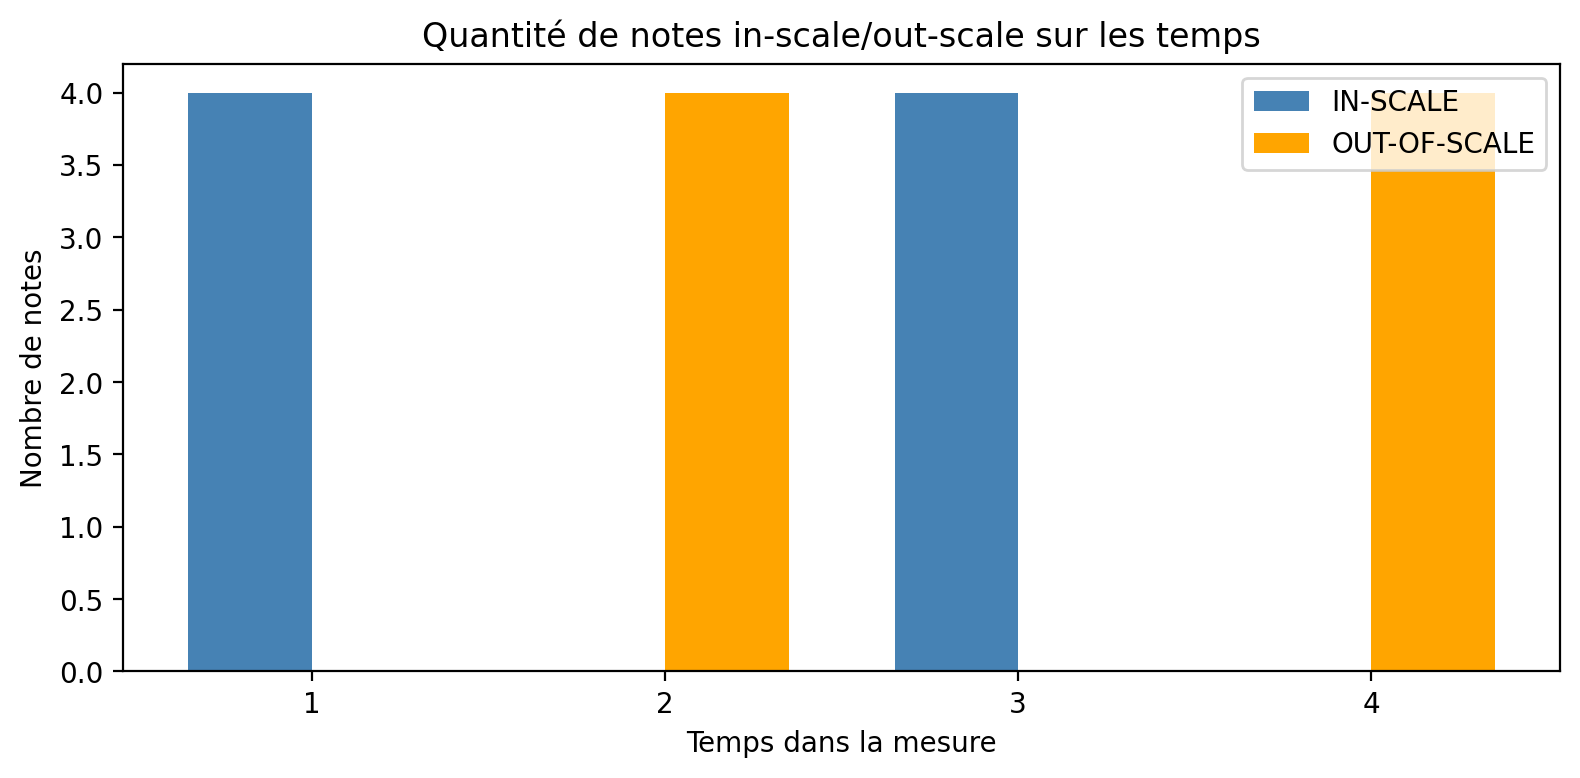

In [17]:
# 1) Préparer les agrégations
# ----------------------------
in_stats = (
    df
    .filter(pl.col("in_scale") == True)
    .group_by("slot4")
    .agg([
        pl.len().alias("count_in"),
        pl.sum("duration_q").alias("dur_in")
    ])
    .sort("slot4")
)

out_stats = (
    df
    .filter(pl.col("in_scale") == False)
    .group_by("slot4")
    .agg([
        pl.len().alias("count_out"),
        pl.sum("duration_q").alias("dur_out")
    ])
    .sort("slot4")
)

# SOLUTION: Obtenir tous les slots uniques présents dans les données
all_slots = sorted(df["slot4"].unique().to_list())

# Créer des dictionnaires pour un accès facile aux counts
in_dict = dict(zip(in_stats["slot4"].to_list(), in_stats["count_in"].to_list()))
out_dict = dict(zip(out_stats["slot4"].to_list(), out_stats["count_out"].to_list()))

# Créer les listes avec des 0 pour les slots manquants
count_in = [in_dict.get(slot, 0) for slot in all_slots]
count_out = [out_dict.get(slot, 0) for slot in all_slots]

# Création d'une seule figure
fig, ax = plt.subplots(figsize=(8, 4))

# Paramètres pour décaler les barres
width = 0.35
x_in = [s - width/2 for s in all_slots]
x_out = [s + width/2 for s in all_slots]

# Tracé des barres IN et OUT
ax.bar(x_in, count_in, width=width, label="IN-SCALE", color='steelblue')
ax.bar(x_out, count_out, width=width, label="OUT-OF-SCALE", color='orange')

# Titres et légendes
ax.set_title("Quantité de notes in-scale/out-scale sur les temps")
ax.set_xlabel("Temps dans la mesure")
ax.set_ylabel("Nombre de notes")
ax.set_xticks(all_slots)
ax.legend()

plt.tight_layout()
plt.show()

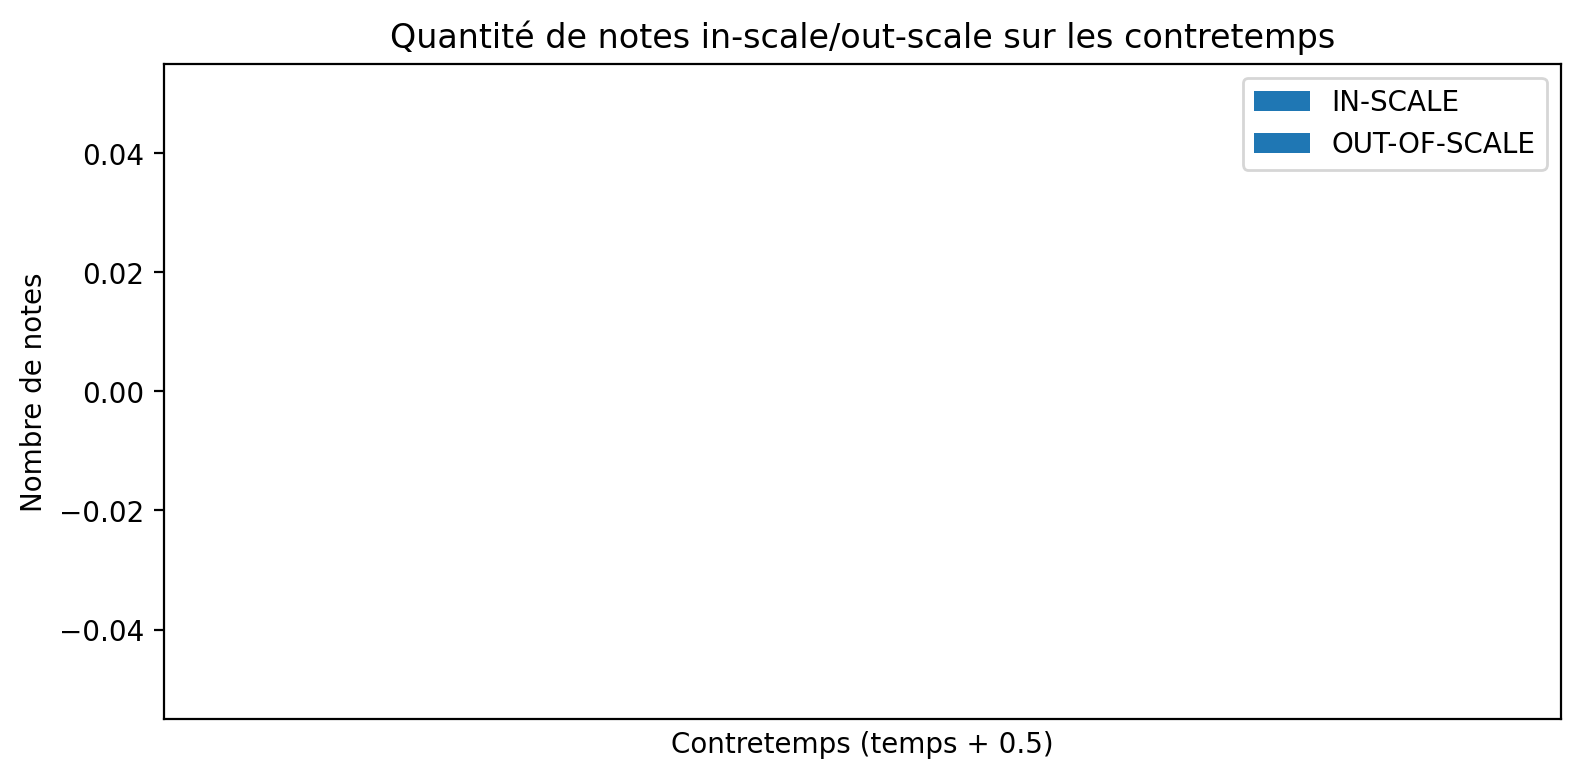

In [ ]:
# 1) Filtrer les contretemps
df_half = (
    df
    # ne garder que les offsets dont la partie fractionnaire est 0.5
    .filter((pl.col("offset_q") % 1) == 0.5)
    # définir slot_half = floor(offset_q) + 0.5, donc 0.5, 1.5, 2.5, 3.5
    .with_columns((np.floor(pl.col("offset_q")) + 0.5).alias("slot_half"))
)

# 2) Agréger les counts IN et OUT pour chaque contretemps
in_stats_half = (
    df_half
    .filter(pl.col("in_scale") == True)
    .group_by("slot_half")
    .agg(pl.len().alias("count_in"))
    .sort("slot_half")
)

out_stats_half = (
    df_half
    .filter(pl.col("in_scale") == False)
    .group_by("slot_half")
    .agg(pl.len().alias("count_out"))
    .sort("slot_half")
)

# SOLUTION: Obtenir tous les contretemps uniques présents dans les données
all_slots_half = sorted(df_half["slot_half"].unique().to_list())

# Créer des dictionnaires pour un accès facile aux counts
in_dict_half = dict(zip(in_stats_half["slot_half"].to_list(), in_stats_half["count_in"].to_list()))
out_dict_half = dict(zip(out_stats_half["slot_half"].to_list(), out_stats_half["count_out"].to_list()))

# Créer les listes avec des 0 pour les contretemps manquants
count_in_half = [in_dict_half.get(slot, 0) for slot in all_slots_half]
count_out_half = [out_dict_half.get(slot, 0) for slot in all_slots_half]

# 4) Tracer la barre comparative
fig, ax = plt.subplots(figsize=(8, 4))

width = 0.35
x_in_half = [s - width/2 for s in all_slots_half]
x_out_half = [s + width/2 for s in all_slots_half]

ax.bar(x_in_half, count_in_half, width=width, label="IN-SCALE", color='steelblue')
ax.bar(x_out_half, count_out_half, width=width, label="OUT-OF-SCALE", color='orange')

ax.set_title("Quantité de notes in-scale/out-scale sur les contretemps")
ax.set_xlabel("Contretemps (temps + 0.5)")
ax.set_ylabel("Nombre de notes")
ax.set_xticks(all_slots_half)
ax.legend()

plt.tight_layout()
plt.show()

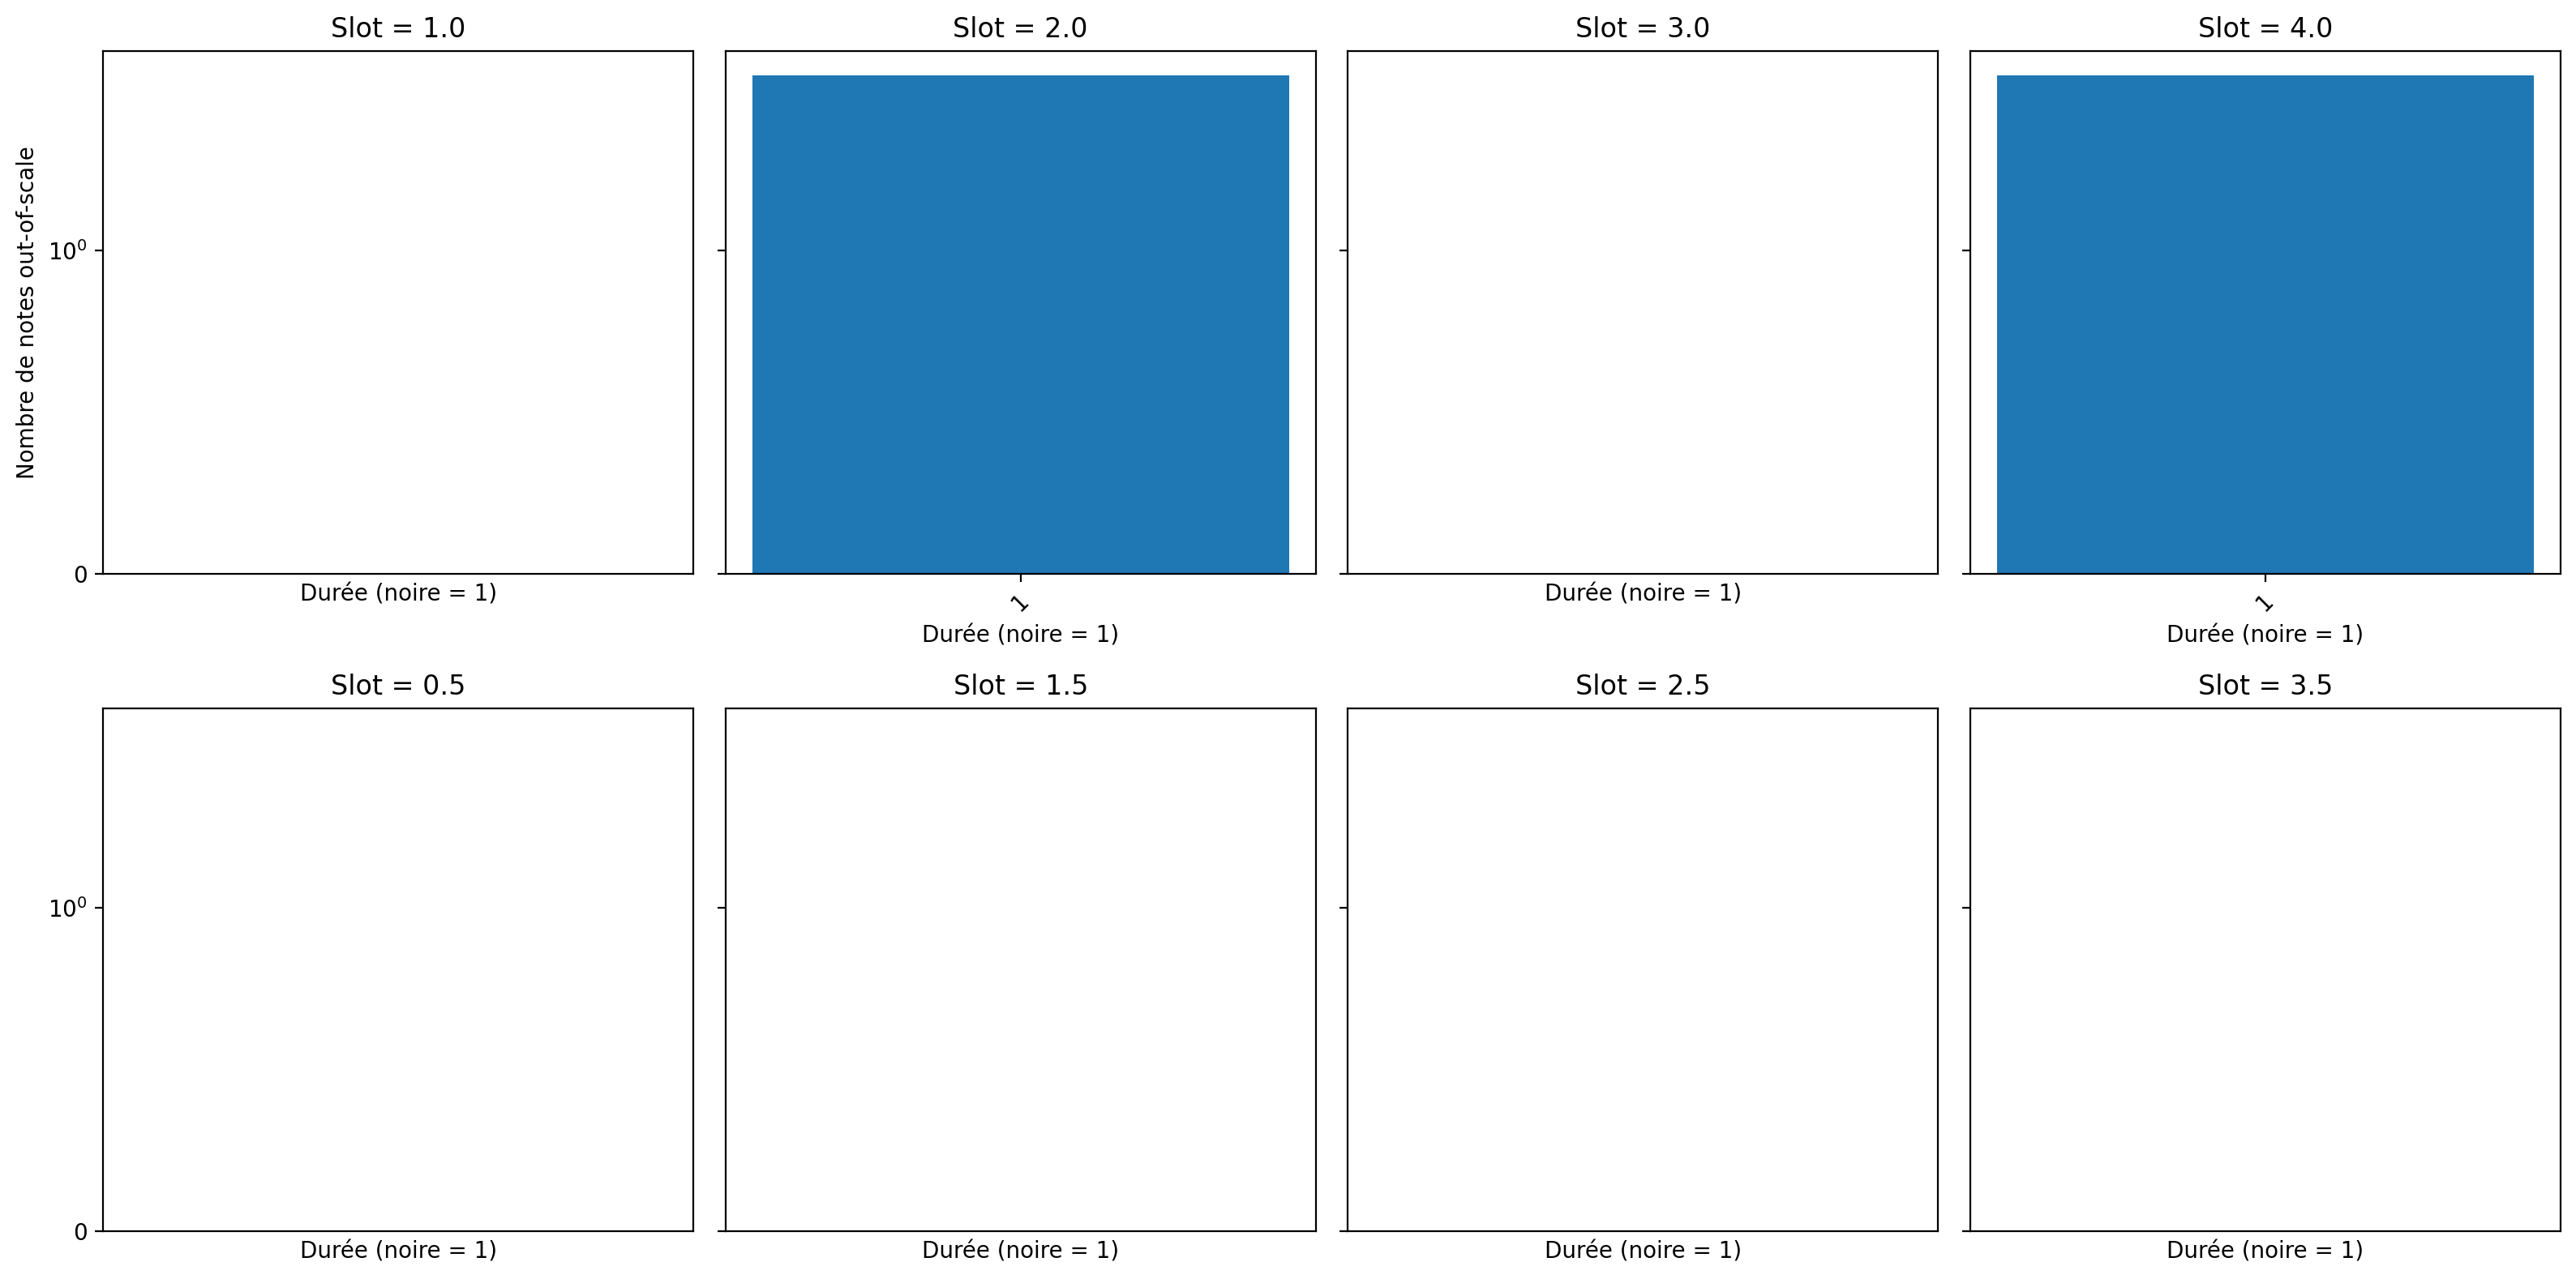

In [8]:
# 2) Construire une colonne 'slot_all' qui regroupe pleins et demi‑temps
df = (
    df
    .with_columns([
        # fraction d’offset
        (pl.col("offset_q") % 1).alias("offset_mod"),
        # contretemps = floor(offset_q) + 0.5
        (np.floor(pl.col("offset_q")) + 0.5).alias("slot_half")
    ])
    .with_columns(
        # par défaut on prend slot4 (1–4), sinon on remplace par slot_half
        pl.when(pl.col("offset_mod") == 0.5)
          .then(pl.col("slot_half"))
          .otherwise(pl.col("slot4"))
          .alias("slot_all")
    )
)
# On crée un DataFrame ne contenant que les notes out‑of‑scale
df_out = df.filter(pl.col("in_scale") == False)

# 3) Les 8 positions à tracer
slots = [1.0, 2.0, 3.0, 4.0, 0.5, 1.5, 2.5, 3.5]

# 4) Grille de 2×4 subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
axes = axes.flatten()


for ax, slot in zip(axes, slots):
    # Filtrer df_out pour le slot courant et passer en pandas
    sub = (
        df_out
        .filter(pl.col("slot_all") == slot)
        .to_pandas()
    )
    
    # Comptage des durations
    counts = sub['duration_q'].value_counts().sort_index()
    
    # Tracé
    ax.bar(counts.index, counts.values, width=0.08)
    ax.set_title(f"Slot = {slot}")
    ax.set_xlabel("Durée (noire = 1)")
    ax.set_xticks(counts.index)
    ax.tick_params(axis='x', rotation=45)
    
    # Échelle semi-log sur l'axe y
    ax.set_yscale('symlog', linthresh=1)

# Label de l’axe y sur le premier subplot
axes[0].set_ylabel("Nombre de notes out-of-scale")

plt.tight_layout()
plt.show()


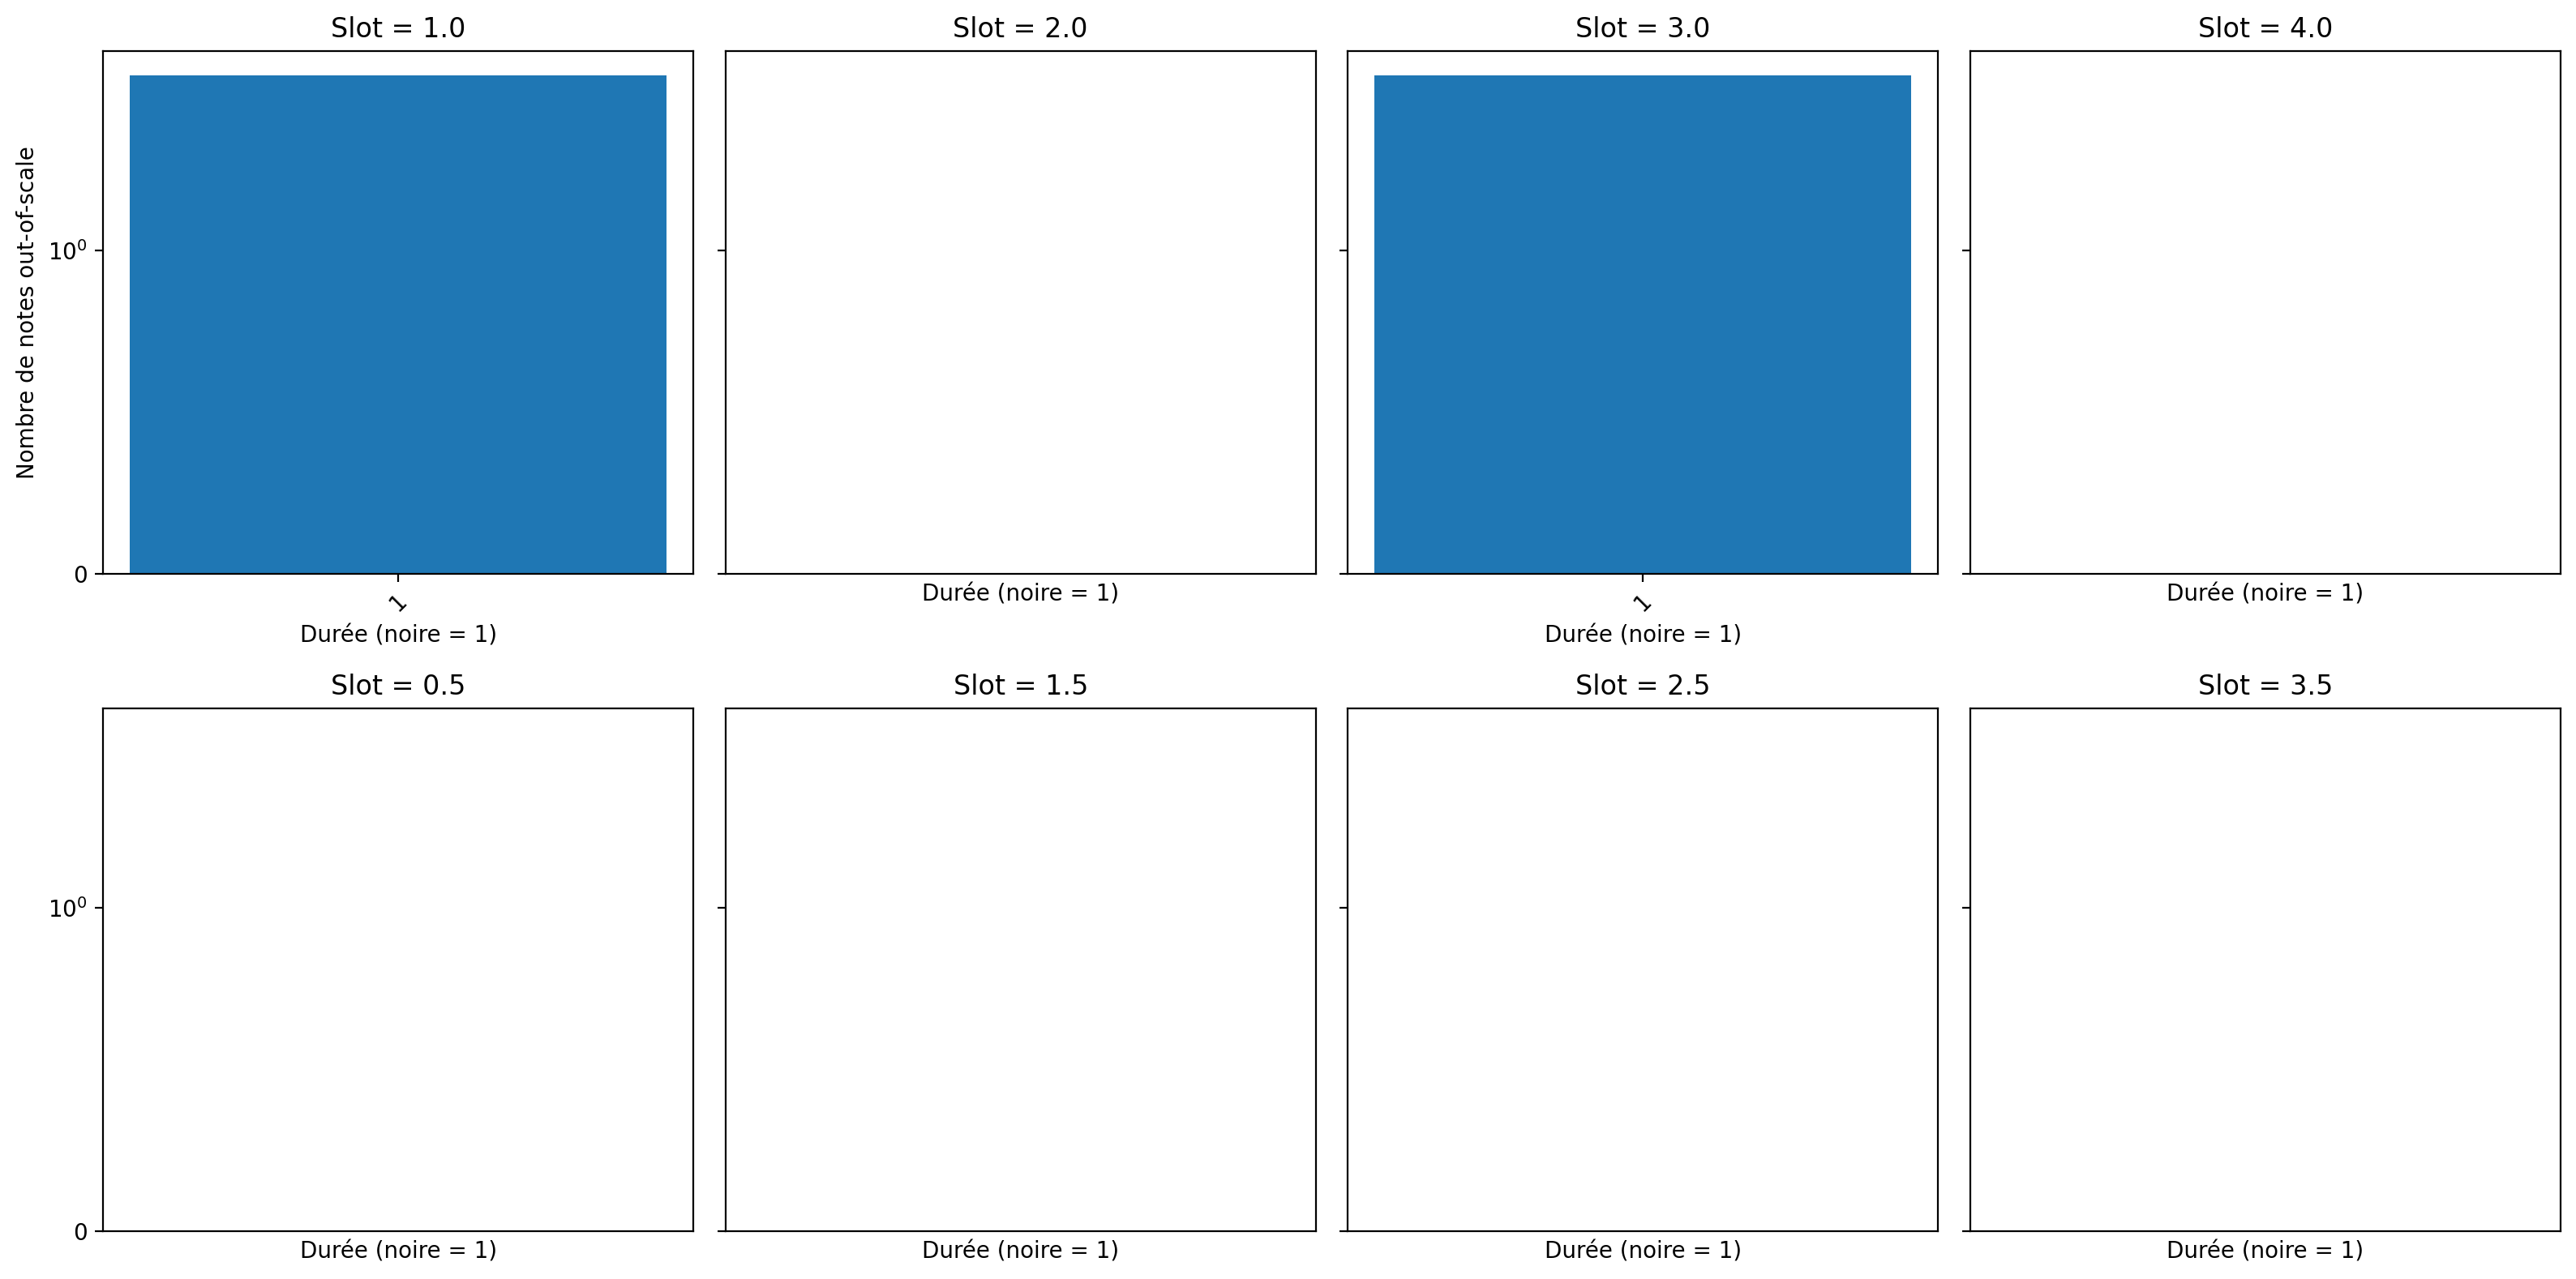

In [9]:
# On crée un DataFrame ne contenant que les notes in‑of‑scale
df_in = df.filter(pl.col("in_scale") == True)

# 3) Les 8 positions à tracer
slots = [1.0, 2.0, 3.0, 4.0, 0.5, 1.5, 2.5, 3.5]

# 4) Grille de 2×4 subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
axes = axes.flatten()


for ax, slot in zip(axes, slots):
    # Filtrer df_out pour le slot courant et passer en pandas
    sub = (
        df_in
        .filter(pl.col("slot_all") == slot)
        .to_pandas()
    )
    
    # Comptage des durations
    counts = sub['duration_q'].value_counts().sort_index()
    
    # Tracé
    ax.bar(counts.index, counts.values, width=0.08)
    ax.set_title(f"Slot = {slot}")
    ax.set_xlabel("Durée (noire = 1)")
    ax.set_xticks(counts.index)
    ax.tick_params(axis='x', rotation=45)
    
    # Échelle semi-log sur l'axe y
    ax.set_yscale('symlog', linthresh=1)

# Label de l’axe y sur le premier subplot
axes[0].set_ylabel("Nombre de notes out-of-scale")

plt.tight_layout()
plt.show()


En analysant des solos de jazz, on essaie de savoir quand un solist joue out de la grille ou non. Pour ce faire, on va évaluer 2 hypothèses :


H0: Le fait de jouer out est indépendant du temps faible/fort.


H1: Les contretemps sont plus souvent des notes courtes.


In [10]:
# On prépare un dataframe avec les
df2 = df.with_columns([
    # offbeat si offset non entier
    pl.when((pl.col("offset_q") % 1) != 0)
      .then(pl.lit("offbeat"))
    # sinon integer : strong sur slot4 1 ou 3, weak sur 2 ou 4
      .otherwise(
          pl.when(pl.col("slot4").is_in([1, 3]))
            .then(pl.lit("strong"))
            .otherwise(pl.lit("weak"))
      )
      .alias("beat_cat"),
    # colonne de comptage
    pl.lit(1).alias("ct")
])
#On rajoute une colonne pour signifier un changement de titre
df3 = df2.with_columns([
    (pl.col("title") != pl.col("title").shift(1))  # comparaison avec la ligne précédente
    .cast(pl.Int8)                                 # True→1, False→0
    .alias("change_flag")
])
df3 = df3.with_columns([
    pl.col("change_flag").cum_sum().alias("segment_id")
])
print(df3.head(10),"\n", df3.columns)

shape: (10, 15)
┌─────────────┬─────────┬───────┬──────────┬───┬──────────┬─────┬─────────────┬────────────┐
│ title       ┆ measure ┆ pitch ┆ offset_q ┆ … ┆ beat_cat ┆ ct  ┆ change_flag ┆ segment_id │
│ ---         ┆ ---     ┆ ---   ┆ ---      ┆   ┆ ---      ┆ --- ┆ ---         ┆ ---        │
│ str         ┆ i64     ┆ str   ┆ f64      ┆   ┆ str      ┆ i32 ┆ i8          ┆ i64        │
╞═════════════╪═════════╪═══════╪══════════╪═══╪══════════╪═════╪═════════════╪════════════╡
│ Out-in play ┆ 1       ┆ C5    ┆ 0.0      ┆ … ┆ strong   ┆ 1   ┆ null        ┆ null       │
│ Out-in play ┆ 1       ┆ B-4   ┆ 1.0      ┆ … ┆ weak     ┆ 1   ┆ 0           ┆ 0          │
│ Out-in play ┆ 1       ┆ D5    ┆ 2.0      ┆ … ┆ strong   ┆ 1   ┆ 0           ┆ 0          │
│ Out-in play ┆ 1       ┆ A-4   ┆ 3.0      ┆ … ┆ weak     ┆ 1   ┆ 0           ┆ 0          │
│ Out-in play ┆ 2       ┆ E-4   ┆ 0.0      ┆ … ┆ strong   ┆ 1   ┆ 0           ┆ 0          │
│ Out-in play ┆ 2       ┆ C#4   ┆ 1.0      ┆ … ┆ weak 